# 📊 Análisis Exploratorio del Dataset Titanic

**Objetivo:**  
Explorar el dataset del Titanic para entender sus variables, detectar problemas en los datos
y encontrar patrones relacionados con la supervivencia.


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("titanic (1).csv")

## 🔎 Vista general del dataset


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.shape

(891, 12)

In [8]:
df.size

10692

## ❓ Preguntas de análisis

- ¿Sobrevivieron más mujeres que hombres? Si, el numero total de mujeres vivas fué de 233 mientras que hombres vivos fué de 109
- ¿Influye la clase social en la supervivencia? Si, la clase social fué determinante para garantizar la supervivencia de las personas
- ¿La edad afecta la probabilidad de sobrevivir? Si, la edad es fundamental para la supervivencia de la persona ya que abajo dice que los niños tuvieron un 57.9% de probabilidad de sobrevivir, a diferencia de los ancianos que solo tuvieron 22.7% de probabilidad de sobrevivir


- ¿Sobrevivieron más mujeres que hombres? Si, hubo mas mujeres que lograron sobrevivir

In [9]:
mujeres_vivas = df[(df["Sex"] == "female") & (df["Survived"] == 1)].shape[0]
hombres_vivos = df[(df["Sex"] == "male") & (df["Survived"] == 1)].shape[0]
print(f"El numero total de mujeres vivas es de {mujeres_vivas}")
print(f"El numero total de hombres vivos es de {hombres_vivos}")

El numero total de mujeres vivas es de 233
El numero total de hombres vivos es de 109


- ¿Influye la clase social en la supervivencia? Si, la clase social fue un factor determinante para garantizar la supervivencia de los pasajeros

In [10]:
df.groupby("Pclass")["Survived"].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

- ¿La edad afecta la probabilidad de sobrevivir? Si, la edad es fundamental para la supervivencia de la persona ya que abajo dice que los niños tuvieron un 57.9% de probabilidad de sobrevivir, a diferencia de los ancianos que solo tuvieron 22.7% de probabilidad de sobrevivir

In [11]:
bins = [0,12,18,30,45,60,80]
labels = ["Niños", "Adolescentes", "Jovenes", "Adultos", "Adultos Mayores", "Ancianos"]
df["Grupos por edad"] = pd.cut(df["Age"], bins=bins, labels=labels)
df.groupby("Grupos por edad")["Survived"].mean() * 100

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1191/759391558.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Grupos por edad")["Survived"].mean() * 100


Grupos por edad
Niños              57.971014
Adolescentes       42.857143
Jovenes            35.555556
Adultos            42.574257
Adultos Mayores    40.740741
Ancianos           22.727273
Name: Survived, dtype: float64

## 💼 Clase social y dinero
* ¿Qué clase tuvo mayor tasa de supervivencia (1ra, 2da, 3ra)? La primer clase fué la que tuvo mayor tasa de supervivencia con un 62.9%
* ¿El precio del boleto (Fare) se relaciona con sobrevivir? Los datos indican que los pasajeros que adquirieron boletos de mayor valor (típicamente asociados a una mejor ubicación en la Primera Clase) presentaron una probabilidad de supervivencia notablemente superior en comparación con aquellos en rangos de precios inferiores
* ¿Las personas que pagaron boletos caros sobrevivieron más? Si ya que en la gráfica se observa que las personas que pagaron boletos mas caros obtuvieron mayor tasa de supervivencia
* ¿La media del precio del boleto es diferente entre sobrevivientes y no sobrevivientes? La media del precio del bolerto entre sobrevivientes y no sobrevivientes si es muy distinta ya que:
   * La media de precio del boleto de los sobrevivientes es de $48.40
   * La media de precio del boleto de los no sobrevivienres es de $22.12

In [12]:
df.groupby("Pclass")["Survived"].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1191/3388725266.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_sup = df.groupby("Price_Range")["Survived"].mean() * 100


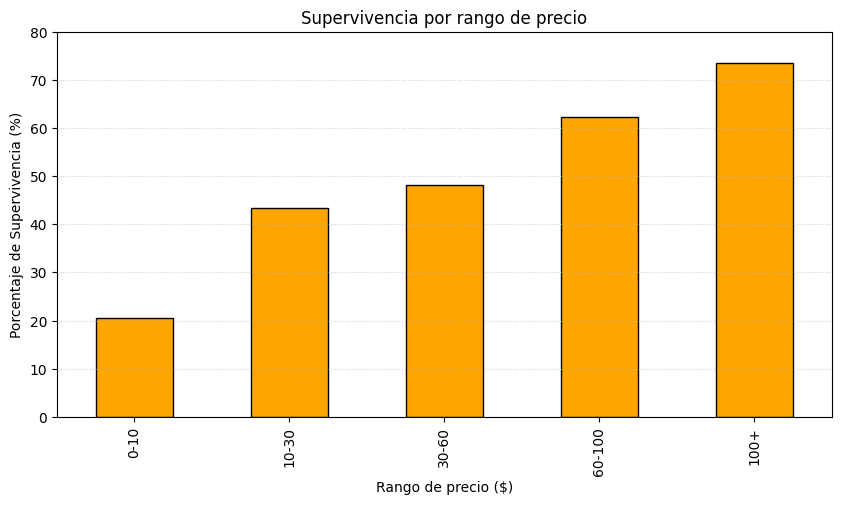

In [13]:
# Crear rangos de precio
bins = [0, 10, 30, 60, 100, 600]
label = ["0-10", "10-30", "30-60", "60-100", "100+"]

# Crear una nueva columna en el Data Frame Original
df["Price_Range"] = pd.cut(df["Fare"], labels=label, bins=bins)

# Sacar la tasa de supervivencia de los "Price_ Range"
tasa_sup = df.groupby("Price_Range")["Survived"].mean() * 100
tasa_sup

# Graficar
import matplotlib.pyplot as plt
tasa_sup.plot(kind="bar",
              color="orange",
              edgecolor = "black",
              figsize=(10,5))
plt.title("Supervivencia por rango de precio")
plt.xlabel("Rango de precio ($)")
plt.ylabel("Porcentaje de Supervivencia (%)")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.ylim(0,80)
plt.show()

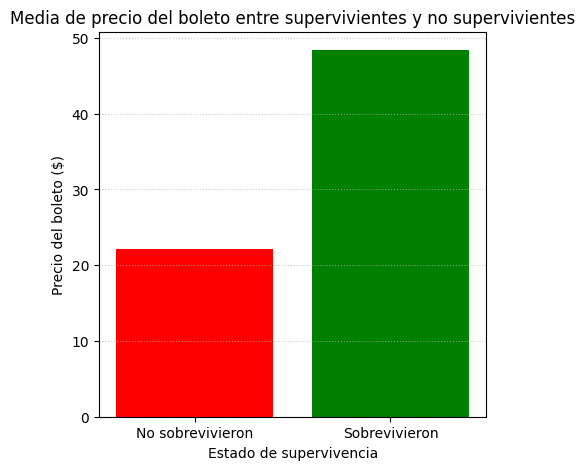

In [48]:
media_boleto = df.groupby("Survived")["Fare"].mean().round(2)
plt.figure(figsize=(5,5))
plt.title("Media de precio del boleto entre supervivientes y no supervivientes")
plt.bar(media_boleto.index, media_boleto.values, color=["red", "green"])
plt.ylabel("Precio del boleto ($)")
plt.xlabel("Estado de supervivencia")
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.xticks(ticks=[0,1], labels=["No sobrevivieron", "Sobrevivieron"])
plt.show()